In [ ]:
# ok so we need all these libraries to make everything work
# pandas and numpy are basically just for handling the data
# matplotlib is for making the graphs look nice at the end
# sklearn has all the actual ML stuff we need like the models and tuning tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')  # just hiding annoying warnings that dont really matter


# 1. Load Data and Initial Split

In [ ]:
# loading in the UAE real estate dataset
csv_filename = "uae_real_estate_cleaned.csv"
df = pd.read_csv(csv_filename)

# price is what we're trying to predict so we separate it from the rest
target_column = "price"
X = df.drop(columns=[target_column])  # everything except price = features
y = df[target_column]                 # just the price column = what we predict

# splitting into 80% for training/validation and 20% we lock away for final testing
# random_state=42 just means the split is always the same every time we run it
X_group1, X_group2, y_group1, y_group2 = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Data loaded successfully!")
print(f"Group 1 (Train/Validation) Size: {X_group1.shape[0]} rows")
print(f"Group 2 (Final Test) Size: {X_group2.shape[0]} rows\n")


Data loaded successfully!
Group 1 (Train/Validation) Size: 3367 rows
Group 2 (Final Test) Size: 842 rows



# 2. K-Fold Cross Validation (Baseline)

In [ ]:
# using 5-fold cross validation - basically splits group1 into 5 chunks
# trains on 4 chunks, tests on 1, repeats 5 times so every chunk gets tested once
# this gives a much more reliable score than just a single train/test split
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# these are the 3 models we're comparing - all using default settings for now (baseline)
# we tune them properly in the next section
models = {
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

print("--- Running K-Fold Cross Validation on Group 1 (Baseline) ---")

cv_results = {}
best_cv_score = float('-inf')
best_model_name = ""

for name, model in models.items():
    # r2 score tells us how well the model explains the variation in price
    # 1.0 = perfect, 0 = no better than just guessing the average price
    scores = cross_val_score(model, X_group1, y_group1, cv=kf, scoring='r2')
    mean_score = np.mean(scores)
    cv_results[name] = mean_score
    print(f"  {name} -> Average R2 Score: {mean_score:.4f}")

    # keeping track of which model did best so far
    if mean_score > best_cv_score:
        best_cv_score = mean_score
        best_model_name = name

print(f"\n Best Baseline Model: {best_model_name} (R2={best_cv_score:.4f})\n")


--- Running K-Fold Cross Validation on Group 1 (Baseline) ---
  Ridge Regression -> Average R2 Score: 0.4341
  Random Forest -> Average R2 Score: 0.5435
  HistGradientBoosting -> Average R2 Score: 0.5637

 Best Baseline Model: HistGradientBoosting (R2=0.5637)



# 3. Hyperparameter Tuning with GridSearchCV

In [ ]:
# ok so this is the main part - hyperparameter tuning
# basically we try out a bunch of different settings for each model
# GridSearchCV tests every possible combination and picks the best one
# n_jobs=-1 just means use all CPU cores so it runs faster

print("--- Hyperparameter Tuning ---\n")

# --- Ridge Regression ---
# alpha controls how much we penalize the model for being too complex
# too low = model overfits (memorizes training data), too high = underfits (too simple)
# so we try a wide range to find the sweet spot
ridge_param_grid = {'alpha': [0.01, 0.1, 1, 10, 100, 500, 1000]}
ridge_grid = GridSearchCV(Ridge(), ridge_param_grid, cv=kf, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_group1, y_group1)
print(f"Ridge Best Params : {ridge_grid.best_params_}  R2={ridge_grid.best_score_:.4f}")

# --- Random Forest ---
# n_estimators = how many trees to build (more = better but slower)
# max_depth = how deep each tree can go (too deep = overfitting)
# min_samples_split = minimum rows needed before splitting a node
# max_features = how many features each tree looks at when splitting
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid,
                       cv=kf, scoring='r2', n_jobs=-1)
rf_grid.fit(X_group1, y_group1)
print(f"Random Forest Best Params : {rf_grid.best_params_}  R2={rf_grid.best_score_:.4f}")

# --- HistGradientBoosting ---
# this one builds trees one at a time where each tree fixes the mistakes of the last
# learning_rate = how much each tree contributes (lower = more careful but needs more trees)
# max_iter = total number of trees to build
# max_depth = depth of each individual tree
# l2_regularization = prevents overfitting similar to ridge's alpha
hgb_param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'l2_regularization': [0.0, 0.1, 1.0]
}
hgb_grid = GridSearchCV(HistGradientBoostingRegressor(random_state=42), hgb_param_grid,
                        cv=kf, scoring='r2', n_jobs=-1)
hgb_grid.fit(X_group1, y_group1)
print(f"HGB Best Params   : {hgb_grid.best_params_}  R2={hgb_grid.best_score_:.4f}")

# now we figure out which tuned model actually won
tuned_scores = {
    "Ridge Regression":     ridge_grid.best_score_,
    "Random Forest":        rf_grid.best_score_,
    "HistGradientBoosting": hgb_grid.best_score_,
}
best_tuned_name = max(tuned_scores, key=tuned_scores.get)
best_tuned_score = tuned_scores[best_tuned_name]

# storing the actual fitted models so we can use the winner in the next step
best_tuned_estimators = {
    "Ridge Regression":     ridge_grid.best_estimator_,
    "Random Forest":        rf_grid.best_estimator_,
    "HistGradientBoosting": hgb_grid.best_estimator_,
}

print(f"\n Best Tuned Model: {best_tuned_name} (R2={best_tuned_score:.4f})")
print(f" Improvement over baseline: {best_tuned_score - cv_results[best_tuned_name]:+.4f}\n")


--- Hyperparameter Tuning ---

Ridge Best Params : {'alpha': 10}  R2=0.4342
Random Forest Best Params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}  R2=0.5853
HGB Best Params   : {'l2_regularization': 0.0, 'learning_rate': 0.2, 'max_depth': 3, 'max_iter': 100}  R2=0.5796

 Best Tuned Model: Random Forest (R2=0.5853)
 Improvement over baseline: +0.0417



# 4. Final Evaluation on Group 2 (Hold-Out Test Set)

In [ ]:
# this is the moment of truth - we finally use group 2 which we haven't touched at all
# first we retrain the winning tuned model on ALL of group 1 (not just 4/5 of it)
# then we predict on group 2 and see how it actually performs on completely unseen data
final_model = best_tuned_estimators[best_tuned_name]
final_model.fit(X_group1, y_group1)

final_predictions = final_model.predict(X_group2)

# R2 = how much of the price variation our model explains (higher = better)
# RMSE = average prediction error in the same units as price (lower = better)
true_r2   = r2_score(y_group2, final_predictions)
true_rmse = np.sqrt(mean_squared_error(y_group2, final_predictions))

print(f" Final Model Performance Report (Tuned):")
print(f"   - Selected Model : {best_tuned_name}")
print(f"   - True R2 Score  (Group 2): {true_r2:.4f}")
print(f"   - True RMSE      (Group 2): {true_rmse:.2f}\n")


 Final Model Performance Report (Tuned):
   - Selected Model : Random Forest
   - True R2 Score  (Group 2): 0.5602
   - True RMSE      (Group 2): 1102108.98



# 5. Model Comparison: Baseline vs Tuned

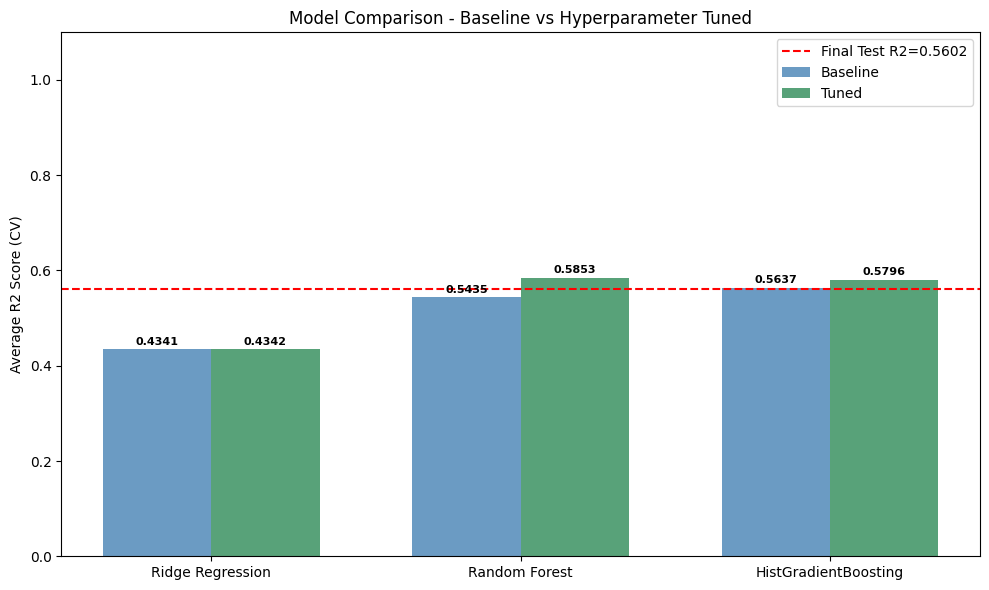

In [ ]:
# making a comparison chart so we can actually see how much the tuning helped
# blue bars = baseline (default settings), green bars = after tuning
# the red dashed line shows the final real-world score on group 2
model_names = list(cv_results.keys())
baseline_scores = [cv_results[n] for n in model_names]
tuned_scores_list = [tuned_scores[n] for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, tuned_scores_list, width, label='Tuned', color='seagreen', alpha=0.8)

ax.set_ylabel('Average R2 Score (CV)')
ax.set_title('Model Comparison - Baseline vs Hyperparameter Tuned')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1)

# this line shows how the best model actually did on the holdout test set
ax.axhline(y=true_r2, color='red', linestyle='--', label=f'Final Test R2={true_r2:.4f}')
ax.legend()

# adding the actual numbers on top of each bar so its easy to read
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


# 4. Model Comparison and Review


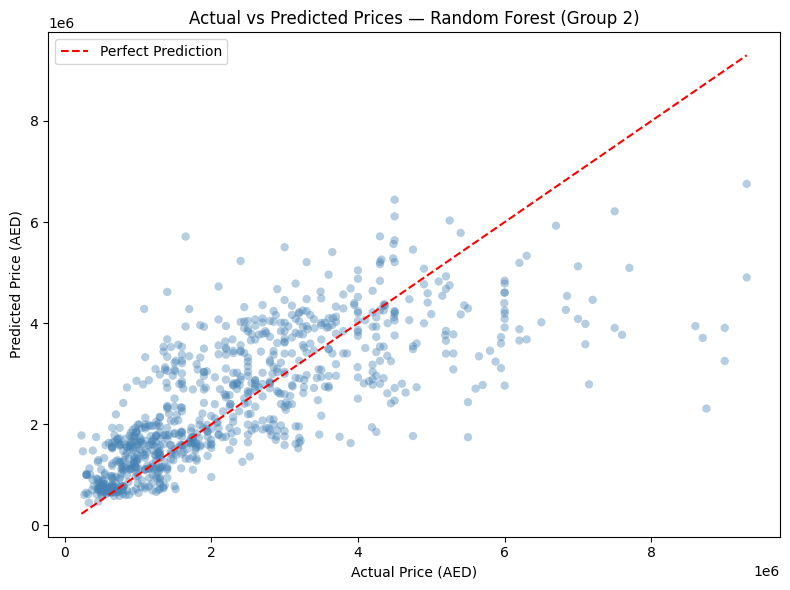

In [ ]:
import seaborn as sns  # for cleaner, more detailed plots alongside matplotlib
# --- Plot 1: Actual vs Predicted Prices (Group 2) ---
# each dot = one property, x = real price, y = what our model guessed
# the red line = perfect predictions, dots close to it = good predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_group2, final_predictions, alpha=0.4, color='steelblue', edgecolors='none')
plt.plot([y_group2.min(), y_group2.max()],
         [y_group2.min(), y_group2.max()],
         color='red', linewidth=1.5, linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Price (AED)')
plt.ylabel('Predicted Price (AED)')
plt.title('Actual vs Predicted Prices — Random Forest (Group 2)')
plt.legend()
plt.tight_layout()
plt.show()

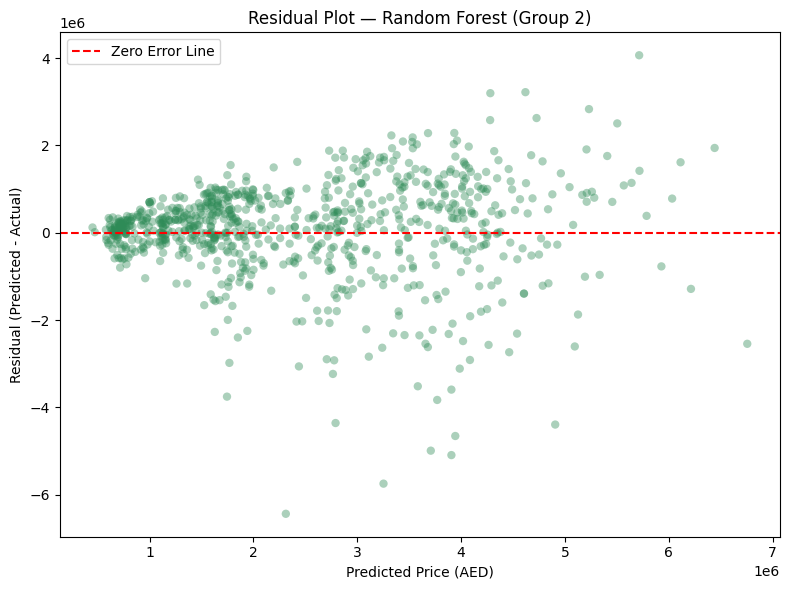

In [ ]:
# --- Plot 2: Residual Plot (Group 2) ---
# residual = predicted price minus actual price
# dots scattered randomly around 0 = good, any pattern = the model has a bias problem
residuals = final_predictions - y_group2

plt.figure(figsize=(8, 6))
plt.scatter(final_predictions, residuals, alpha=0.4, color='seagreen', edgecolors='none')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')

plt.xlabel('Predicted Price (AED)')
plt.ylabel('Residual (Predicted - Actual)')
plt.title('Residual Plot — Random Forest (Group 2)')
plt.legend()
plt.tight_layout()
plt.show()

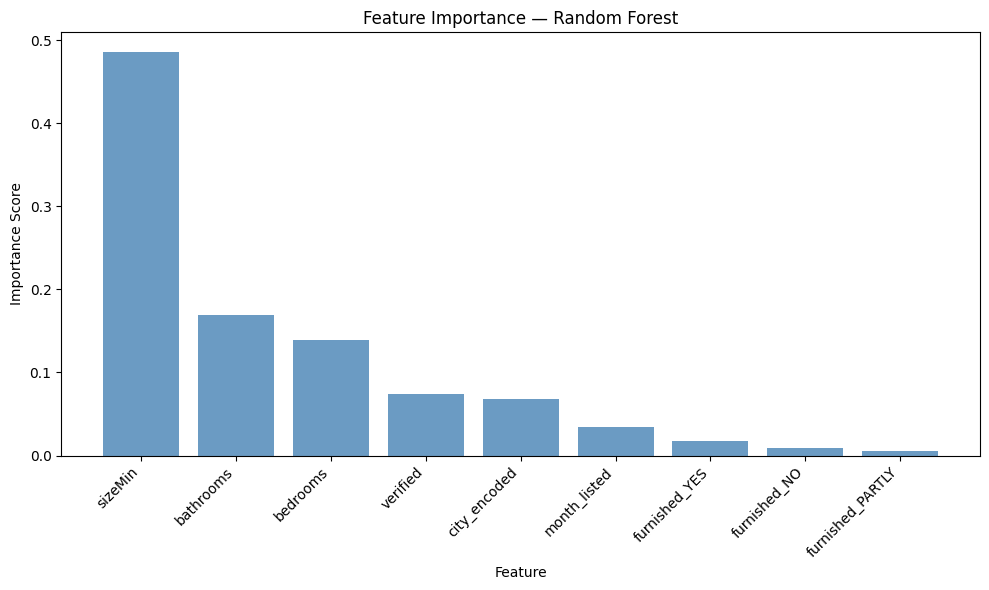

In [9]:
# --- Plot 3: Feature Importance — Random Forest ---
# shows which features the model used most when deciding the predicted price
# higher bar = that feature had more influence on predictions
feature_names = X_group1.columns
importances = final_model.feature_importances_

# sorting features from most to least important so the chart is easy to read
sorted_indices = np.argsort(importances)[::-1]
sorted_importances = importances[sorted_indices]
sorted_names = feature_names[sorted_indices]

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_names)), sorted_importances, color='steelblue', alpha=0.8)
plt.xticks(range(len(sorted_names)), sorted_names, rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

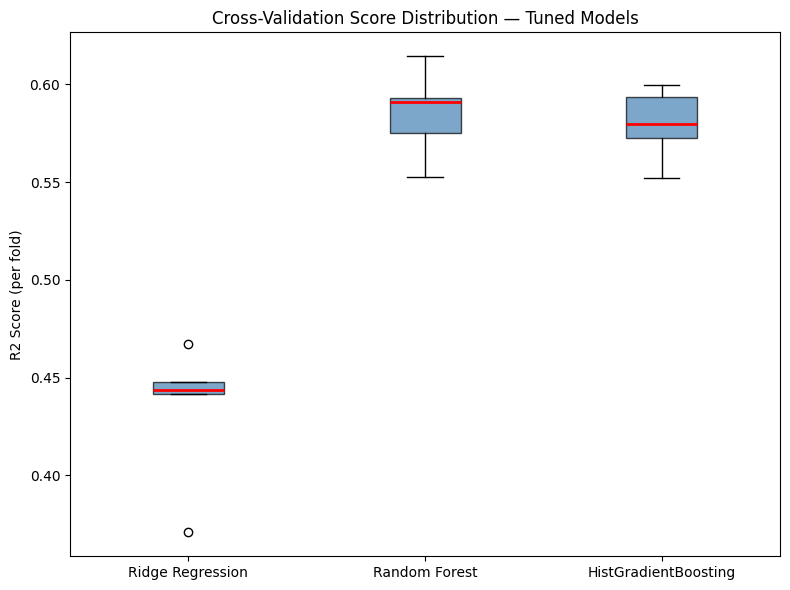

In [10]:
# --- Plot 4: Cross-Validation Score Distribution (Box Plot) ---
# instead of just showing the average R2, this shows the spread across all 5 folds
# a short box sitting high = consistent and accurate, tall box = unstable performance
all_cv_scores = {}

for name, model in best_tuned_estimators.items():
    # re-running CV with the tuned version of each model to get the 5 individual fold scores
    scores = cross_val_score(model, X_group1, y_group1, cv=kf, scoring='r2')
    all_cv_scores[name] = scores

plt.figure(figsize=(8, 6))
plt.boxplot(all_cv_scores.values(), labels=all_cv_scores.keys(), patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))

plt.ylabel('R2 Score (per fold)')
plt.title('Cross-Validation Score Distribution — Tuned Models')
plt.tight_layout()
plt.show()

In [11]:
# --- Summary Table: All Models Baseline vs Tuned vs Final Test ---
# brings all the key numbers together in one place for easy comparison
# final test score only applies to the winning model (Random Forest)
print("=" * 62)
print(f"{'Model':<25} {'Baseline R2':>12} {'Tuned R2':>10} {'Test R2':>10}")
print("=" * 62)

for name in models.keys():
    baseline = cv_results[name]
    tuned    = tuned_scores[name]
    # only the best tuned model was evaluated on group 2, so show '-' for the others
    test     = f"{true_r2:.4f}" if name == best_tuned_name else "-"
    print(f"{name:<25} {baseline:>12.4f} {tuned:>10.4f} {test:>10}")

print("=" * 62)
print(f"\n Final selected model : {best_tuned_name}")
print(f" Group 2 R2           : {true_r2:.4f}")
print(f" Group 2 RMSE         : {true_rmse:.2f} AED")

Model                      Baseline R2   Tuned R2    Test R2
Ridge Regression                0.4341     0.4342          -
Random Forest                   0.5435     0.5853     0.5602
HistGradientBoosting            0.5637     0.5796          -

 Final selected model : Random Forest
 Group 2 R2           : 0.5602
 Group 2 RMSE         : 1102108.98 AED
